# 🚀 실습 시작하기 — 이 노트북 하나로 세팅 끝

**여기서 API 키 발급 → 입력 → 연결 확인까지 마치고** Day01·02 실습으로 넘어갑니다.
LLM은 **NVIDIA build 무료 API**를 씁니다(각자 키 발급). 임베딩·벡터DB는 내 노트북에서 로컬로 돌아갑니다.

| Day | 실습 | LLM(키) 필요? |
|---|---|---|
| 00 | 딥러닝 기초 (PyTorch) | ❌ Colab GPU |
| 01 | RAG QA 봇 | ✅ NVIDIA |
| 02 | 고급 검색(하이브리드·리랭커·HyDE) | ✅ NVIDIA |
| 03 | MCP / FastMCP | ❌ 로컬 |
| 04 | Resource 기반 MCP | ❌ 로컬 |

---

## 1. NVIDIA API 키 발급 (최초 1회, 무료)
<https://build.nvidia.com> 에 로그인(Gmail 등, 카드 불필요) 후 아래 순서로 키를 만듭니다.

### 1-1. 계정 메뉴 → API Keys
우측 상단 **계정 아바타** 클릭 → **API Keys** 선택. (이 메뉴에 내 한도 **`Up to 40 rpm`** 도 보입니다.)

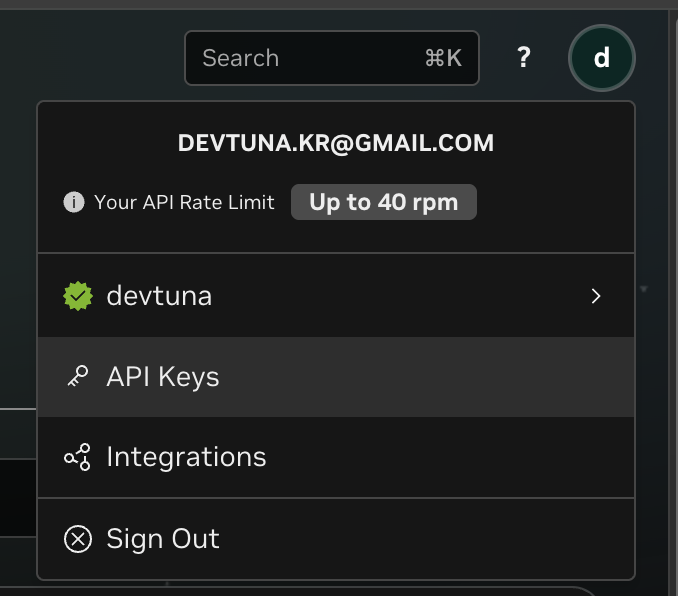

### 1-2. 키 생성
**Generate API Key** 클릭 →

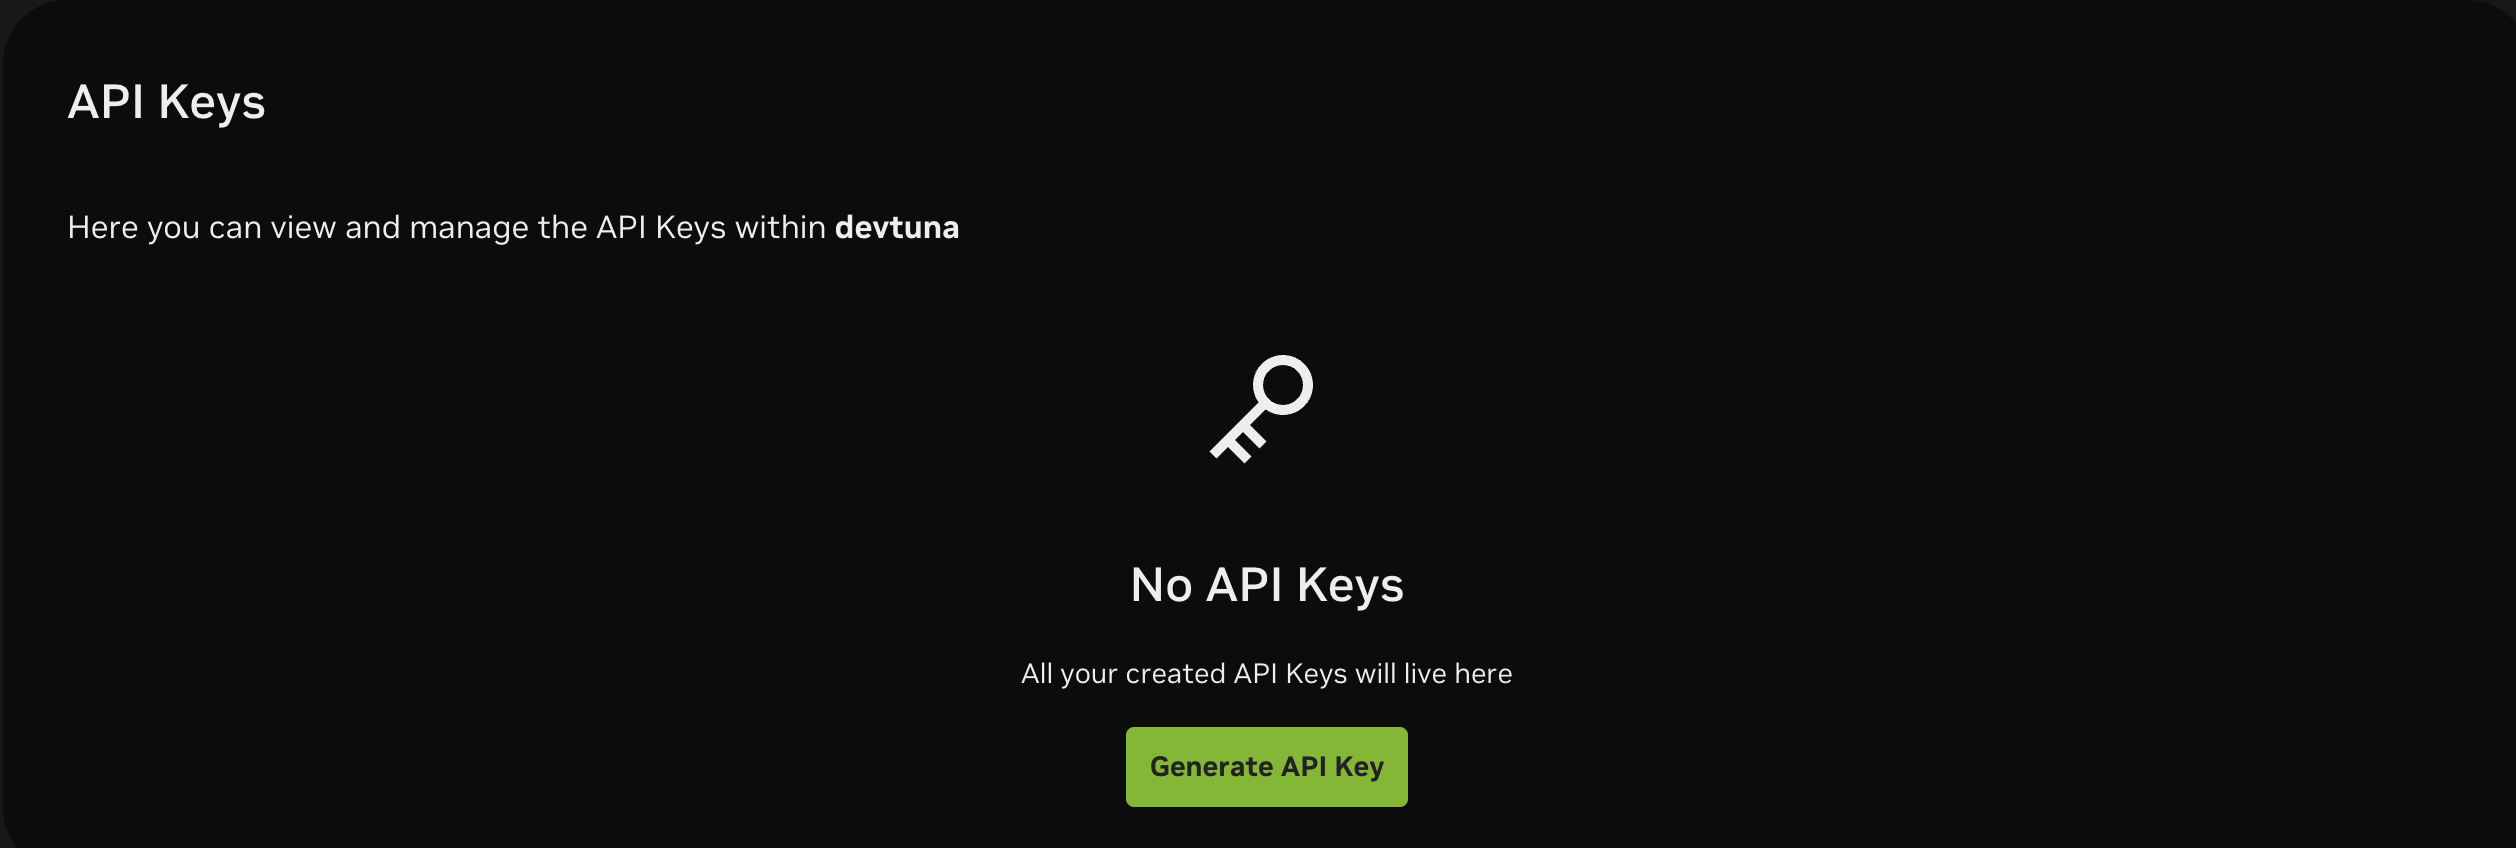

이름 아무거나 입력, **Expiration: `Never Expire`** 선택 → **Generate Key**.

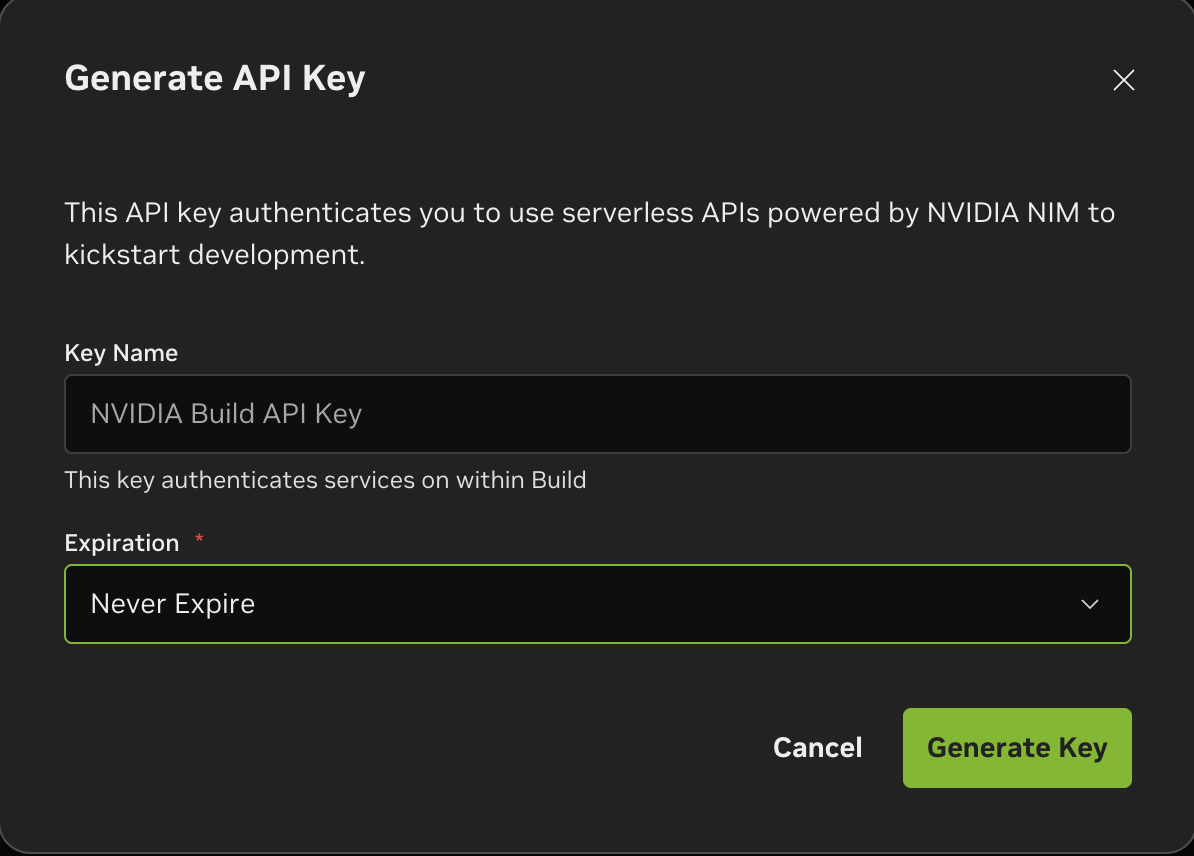

### 1-3. (처음이면) 전화번호 인증
전화번호 OTP 인증 창이 뜰 수 있습니다. 국가·번호 입력 → **Send Code to Phone** → 문자 코드 입력.
(번거로우면 **Skip** 가능 · 한국 계정 발급 확인됨)

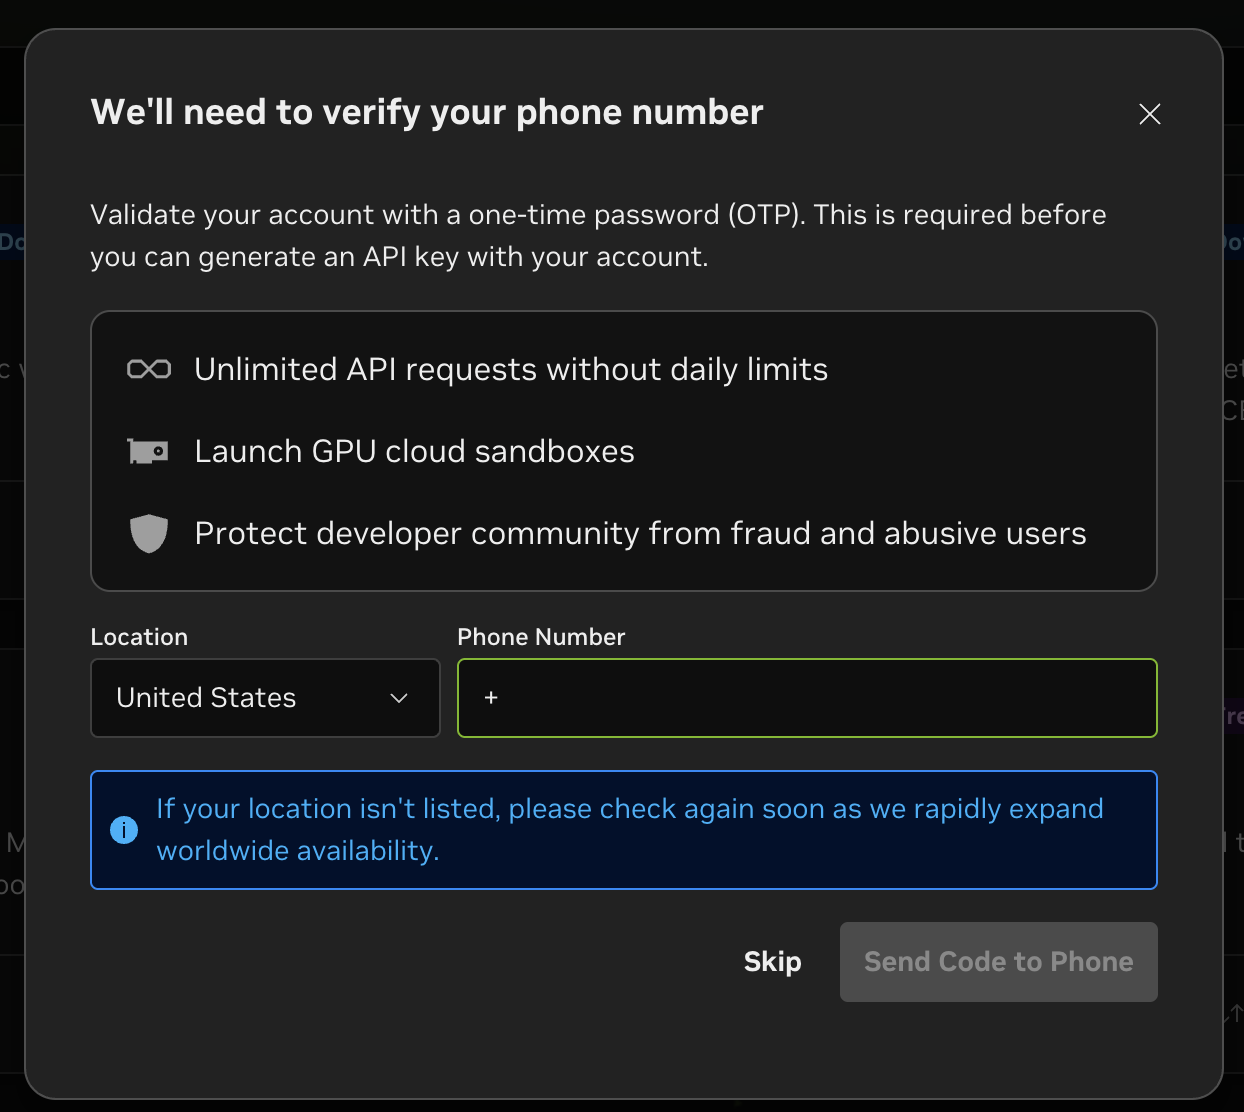

### 1-4. 키 복사 ⚠️ (이 화면에서만 보임!)
**Copy API Key** 로 복사해 안전한 곳에 저장하세요. **다시는 안 보여줍니다.** (`nvapi-...` 로 시작)

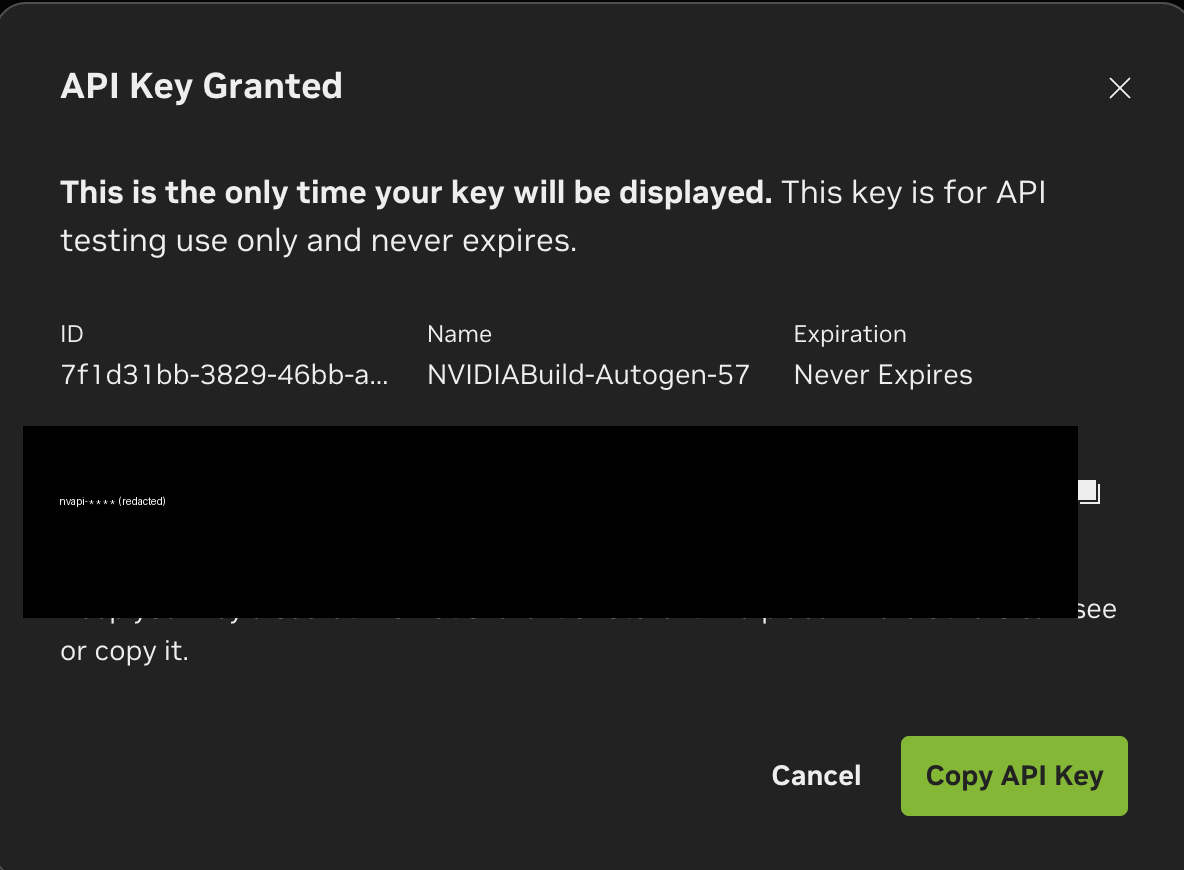

---

## 2. 설치
아래 셀 실행 (한 번).

In [ ]:
!pip install -q openai sentence-transformers qdrant-client langchain-text-splitters rank_bm25 pypdf

## 3. 키 입력 & 연결 테스트
아래 셀을 실행하면 키를 물어봅니다 — **입력값은 화면에 안 보입니다**(안전).
연결되면 사용 가능한 Qwen 모델과 테스트 답변이 출력됩니다.

In [ ]:
import os, getpass
from openai import OpenAI

# 엔드포인트: NVIDIA build (기본). 강사 DGX로 바꾸려면 아래 줄 주석 해제.
QWEN_BASE_URL = os.getenv("QWEN_BASE_URL", "https://integrate.api.nvidia.com/v1")
# QWEN_BASE_URL = "http://124.51.229.210:30001/v1"   # ← 강사 DGX 백업

# 키: 환경변수 있으면 그걸, 없으면 직접 입력(화면에 안 보임)
QWEN_API_KEY = os.getenv("NVIDIA_API_KEY") or os.getenv("QWEN_API_KEY") or getpass.getpass("NVIDIA API 키(nvapi-...) 입력: ")

client = OpenAI(base_url=QWEN_BASE_URL, api_key=QWEN_API_KEY)

# 사용 가능한 모델에서 Qwen 채팅 모델 자동 확정
avail = [m.id for m in client.models.list().data]
LLM_MODEL = os.getenv("LLM_MODEL", "qwen/qwen3-next-80b-a3b-instruct")
if LLM_MODEL not in avail:
    q = [m for m in avail if m.startswith("qwen/") and not any(x in m for x in ("vl", "embed", "rerank"))]
    LLM_MODEL = q[0] if q else avail[0]
print("사용 가능한 Qwen 모델:", [m for m in avail if "qwen" in m.lower()][:6])
print("선택된 모델:", LLM_MODEL)

r = client.chat.completions.create(model=LLM_MODEL, max_tokens=60, temperature=0.2,
    messages=[{"role": "user", "content": "한 문장으로 자기소개 해줘."}])
print("\n✅ 연결 성공! 테스트 답변:", r.choices[0].message.content.strip())

## 4. 이제 실습으로 👉
- **Day01_RAG_실습.ipynb** → **Day02_고급검색_실습.ipynb** 순서
- 각 노트북 상단 **설정 셀**에서 **같은 nvapi 키를 다시 입력**하면 됩니다
- 매번 입력이 번거로우면 각 노트북 첫 셀에:
  ```python
  import os; os.environ["NVIDIA_API_KEY"] = "nvapi-..."
  ```
  를 넣어두면 이후 자동 사용됩니다.

> 🔒 키는 비밀입니다 — 코드에 직접 적지 말고 `getpass`로 입력(그래서 커밋·화면공유에 노출 안 됨).